In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END  # framework that helps you design and manage the flow of tasks in your application using a graph

class AgentState(TypedDict):
    num1 : int
    num2 : int
    operation : str
    output : int

In [18]:
def adder(state: AgentState) -> AgentState:
    """This node adds two numbers"""
    state["output"] = state["num1"] + state["num2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts two numbers"""
    state["output"] = state["num1"] - state["num2"]
    return state

def decide_next_node(state: StateGraph) -> str:
    """ Decides the operation"""
    if state['operation'] == '_add_':
        return 'adder'
    elif state['operation'] == '__sub__':
        return 'sub'


def square(state: AgentState) -> AgentState:
    """This node squares the output"""
    state["output"] = state["output"] ** 2
    return state

def cube(state: AgentState) -> AgentState:
    """This node cubes the output"""
    state["output"] = state["output"] ** 3
    return state

def decide_square_or_cube(state: StateGraph) -> str:
    """Decides whether to square or cube the output"""
    if state['operation'] == '_add_':
        return 'square'
    else:
        return 'cube'

In [19]:
graph = StateGraph(AgentState)

graph.add_node('adder_node', adder)
graph.add_node('sub_node', subtractor)
graph.add_node('router', lambda state:state)  # This node will route to the next node based on the operation

graph.add_node('square', square)
graph.add_node('cube', cube)
graph.add_node('router2', lambda state:state)  # This node will route to the next node based on the output

graph.add_edge(START, 'router')

graph.add_conditional_edges("router", decide_next_node, { 
    'adder' : 'adder_node',
    'sub' : 'sub_node'
})


graph.add_edge('adder_node', 'router2')
graph.add_edge('sub_node', 'router2')


graph.add_conditional_edges("router2", decide_square_or_cube, {
    'square' : 'square',
    'cube': 'cube'
})


graph.add_edge('square', END)
graph.add_edge('cube', END)

app = graph.compile()



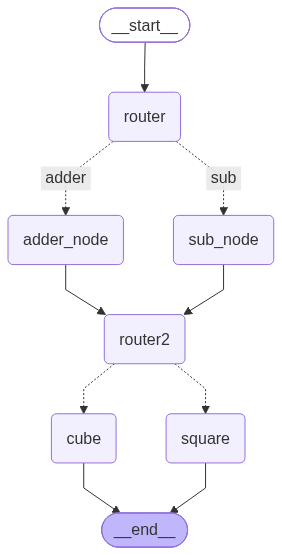

In [20]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
app.invoke({"num1": 5, "num2": 5, "operation": "_add_"})

{'num1': 5, 'num2': 5, 'operation': '_add_', 'output': 100}